# Spår B – Klassificering (identifiera “högpris-områden”) 

#### Bakgrundshistoria

 Kunden vill bygga ett verktyg som kan användas när ett nytt område (eller ett område som inte är analyserat ännu) dyker upp. De har tillgång till områdets egenskaper (geografi, hushåll, inkomstnivåer osv.) men de vet inte bostadsvärdet än.
 För att prioritera var man ska lägga tid och resurser vill de kunna få en snabb klassning: ”ser detta ut som ett högpris-område?”

#### Uppdrag

- Skapa en binär target high_value i historisk data:
high_value = 1 om median_house_value ligger i topp 20%
annars 0
- Träna en modell som förutsäger high_value utifrån X-variablerna (t.ex. median_income, geografi, hushållsvariabler, ocean_proximity, osv.)
- När du tränar modellen får du bara använda X-variablerna (alla kolumner utom median_house_value och din target high_value)

#### Viktigt

 När modellen används på nya områden finns inte median_house_value tillgängligt.
 Därför får median_house_value inte ingå som input-feature i klassificeringen (den används endast för att skapa target i träningsdatan).

#### Syfte

Att kunna prioritera områden och resonera om vilka typer av fel som är mest problematiska (t.ex. missa ett högpris-område vs flagga ett område i onödan).
Målet är inte att gissa priset, utan att snabbt flagga områden som sannolikt är högpris så att teamet kan prioritera.


In [45]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from scipy.sparse import hstack
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    silhouette_score
)

sns.set_context("notebook")



## Load data

In [46]:
df = pd.read_csv("housing.csv")

print("\n Dataset columns excerpt:")
print(df.head())


 Dataset columns excerpt:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


## 1) Dataförståelse & EDA 

 Krav:
- Visa datasetets storlek, datatyper och vilka features som finns.
- Kontrollera saknade värden och beskriv kort hur du hanterar dem.
- Minst 2 relevanta figurer/tabeller + kort tolkning.

In [47]:
print("\nDatasetets storlek:\n", df.shape)
print("---------------------------")


Datasetets storlek:
 (20640, 10)
---------------------------


In [48]:
print("\nDatatyper:\n", df.dtypes)
print("---------------------------")


Datatyper:
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object
---------------------------


In [49]:
print("\nFeatures i datasetet:\n", df.columns)
print("---------------------------")


Features i datasetet:
 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')
---------------------------


### Summering av dataset

- Datsetet innehåller 20640 observationer och 10 variabler.
- Av dem 10 variablerna är 9 numeriska variabler av typerna float64 och 1 är en kategorisk variabel av typen objekt - *ocean_proximity*.
- Target är baserat på *median_house_value*. 


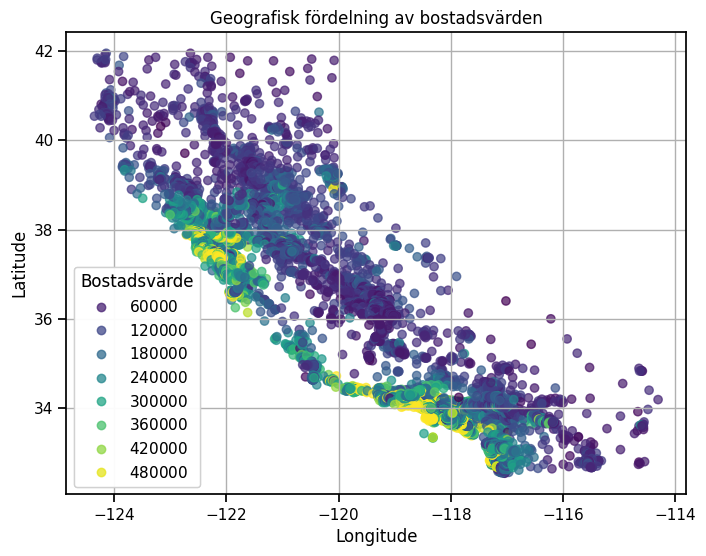

In [50]:
fig, ax = plt.subplots(figsize=(8,6))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap= plt.get_cmap("viridis"),
    alpha=0.7
)
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="lower left", title="Bostadsvärde")
ax.add_artist(legend1)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geografisk fördelning av bostadsvärden")
ax.grid(True)

plt.show()

#### Geografisk fördelning av bostadsvärden

Den geografiska scatterploten visar tydliga kluster där bostadsvärden är högre, framför allt längs kusten.
Detta bekräftar att geografi är en starkt förklarande variabel och motiverar varför longitude och latitude bör ingå i modellen.
Figuren hjälper även stakeholders att intuitivt förstå varför vissa områden systematiskt har högre värden.

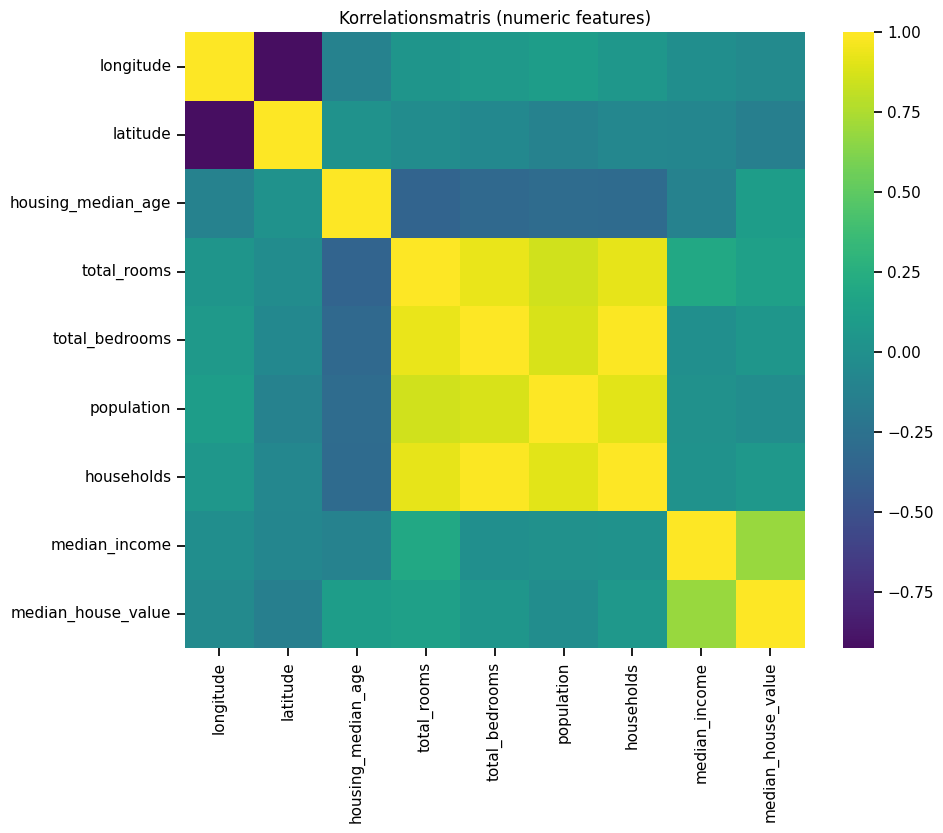

In [51]:
corr_matrix = df[["longitude","latitude","housing_median_age","total_rooms", "total_bedrooms","population", "households","median_income","median_house_value"]].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,cmap="viridis", center=0)
plt.title("Korrelationsmatris (numeric features)")
plt.show()

#### Korrelationsmatris (numeric features)

Det finns ett tydligt samband mellan *median_income* och *median_house_value* - en nog ganska förväntad korrelation. Det är också väldigt starka korrelationer mellan variablerna *total_rooms*, *total_bedrooms*, *population* och *households* vilket tyder på att det beskriver liknande strukturella egenskaper i områdena.
Modellen kan därför behöva regularisering för att hantera dessa överlappande signaler.
*Longitude* och *latitude* har svagare korrelationer med bostadsvärde i matrisen, men deras effekt är icke‑linjär så syns bättre i scatterploten.

### Saknade värden

In [52]:
print("\nSaknade värden (antal):\n", df.isna().sum())
print("-------------------------------")
print("\nSaknade värden (%):\n", df.isna().sum()/len(df)*100)
print("-------------------------------")


Saknade värden (antal):
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
-------------------------------

Saknade värden (%):
 longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64
-------------------------------


### Summering av hantering av saknade värden

Andelen saknade värden är väldigt låg - *total_bedrooms*(1%). För en numerisk variabel med så lite saknade värden är SimpleImputer(strategy="median") den mest effektiva lösningen och best practice. För att minska leakage kommer saknade värden imputeras i pipeline genom att median-imputering beräknas på träningsdatan och sedan att samma transformation appliceras på testdata. 

---


## 2) Target Engineering (Skapa y)

Steg 1 av uppdraget: 
- Skapa en binär target high_value i historisk data:
- high_value = 1 om median_house_value ligger i topp 20%
- annars 0

In [53]:
threshold = df["median_house_value"].quantile(0.80) #Skapar binär target high_value -> använder quantile(0.80) för att hitta gränsen för topp 20% dyraste bostäder
df["high_value"] = (df["median_house_value"] >= threshold).astype(int) #Skapar en ny binär kolumn: high_value baserat på threshold.

y = df["high_value"]

### Summering av target engineering

För att omvandla problemet till en binär klassificeringsuppgift definierades en ny target‑variabel, *high_value*.
Tröskeln sattes till 80:e percentilen av , vilket motsvarar de 20% dyraste bostäderna.
Den definieras som 1 om *median_house_value* ligger i topp 20%, annars 0.
Detta gör det möjligt att identifiera premiumområden utan att behöva förutsäga exakta priser.

---

## 3) Feature Engineering (transformera X)

Variabeln income_cat skapades för att gruppera median_income i fem socioekonomiskt relevanta nivåer.
Den används för analys och kan även användas för stratifiering

In [54]:
df["income_cat"] = pd.cut(
    df["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
) 

X = df.drop(["median_house_value", "high_value", "income_cat"], axis=1)

In [55]:
print("X:", X.shape, "y:", y.shape)
print("---------------------------")

print("\n Income category distribution (whole dataset):")
print(df["income_cat"].value_counts())
print("---------------------------")

X: (20640, 9) y: (20640,)
---------------------------

 Income category distribution (whole dataset):
income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64
---------------------------


### Summering av feature engineering

Income cat skapar kategoriska intervall från den kontinuerliga variabeln. Den omvandlar en numerisk kolumn till 5 ordnade kategorier som sedan kan användas för stratifierat urval.
Gränserna för intervallen valdes utifrån tre principer: den statistiska fördelningen, socioekonomisk relevans samt att varje intervall skulle innehålla tillräckligt många observationer för att möjliggöra stratifiering.

---

## 4) Split + preprocessing

 Krav:
- Dela datan i train och test.
- Klassificering: använd stratifierad split (stratify) så att klasserna fördelas rimligt i train/test.
- Preprocessing ska göras på ett sätt som undviker att testdata påverkar träningen.

### Train/test split

In [56]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.25,
    random_state = 42,
    stratify= y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train postive rate:", y_train.mean().round(3), "Test postive rate:", y_test.mean().round(3))


display(X_train.head()) 

print("\nSaknade värden (train)")
print(X_train.isna().sum().sort_values(ascending=False).head(10))

print("\nSammanfattning (train)")
print(X_train.describe().T.head(10))

Train: (15480, 9) Test: (5160, 9)
Train postive rate: 0.2 Test postive rate: 0.2


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
7767,-118.10,33.91,29.0,505.0,113.0,411.0,113.0,2.6397,<1H OCEAN
16846,-122.41,37.62,49.0,1464.0,302.0,636.0,259.0,4.2500,NEAR OCEAN
3875,-118.54,34.19,33.0,2205.0,453.0,1242.0,419.0,4.1319,<1H OCEAN
2873,-118.96,35.37,41.0,1463.0,339.0,1066.0,318.0,1.7467,INLAND
13095,-121.37,38.56,27.0,1827.0,509.0,852.0,450.0,2.0901,INLAND



Saknade värden (train)
total_bedrooms        159
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

Sammanfattning (train)
                      count         mean          std       min          25%  \
longitude           15480.0  -119.571565     2.004815 -124.3500  -121.810000   
latitude            15480.0    35.631242     2.136372   32.5400    33.930000   
housing_median_age  15480.0    28.657946    12.543823    1.0000    18.000000   
total_rooms         15480.0  2632.472868  2168.268647    2.0000  1444.000000   
total_bedrooms      15321.0   536.994583   419.708406    1.0000   295.000000   
population          15480.0  1423.167119  1142.025324    3.0000   786.000000   
households          15480.0   498.787726   380.993845    1.0000   280.000000   
median_income       15480.0     3.876972     1.906427    0.4999  

### Summering av train/test split

Vi delar upp datan i tränings- och testset med en 75/25-fördelning. 
Stratify=y_full garanterar att andelen lyxbostäder och lågris bostäder fall är proportionerligt lika i både tränings- och testset.

### Preprocessing


In [57]:
numeric_features = ["longitude","latitude","housing_median_age","total_rooms","total_bedrooms","population","households","median_income"]
categorical_features = ["ocean_proximity"]


In [58]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)



### Summering av preprocess

2 transformers skapas:
- numerisk transformer hanterar saknade värden med medianvärdet och standardiserar sedan värdena med StandardScaler.
- kategorisk transformer fyller saknade värden fyller saknade värden med "most_frequent",  följt av OneHotEncoder som omvandlar textvärden till binära kolumner som modellen kan tolka.

Dem två transformers slås ihop i en ColumnTransformer som applicerar rätt transformer på rätt kolumner.


---

## 5) Modellering

 Krav:
- Skapa en baseline.
- Träna minst två ytterligare modeller (totalt minst 3 inkl baseline).
- Jämför modellerna med en tydlig utvärderingsmetod (t.ex. cross-validation eller valideringsupplägg).

In [59]:
lr = LogisticRegression(max_iter=500, random_state=42)
rf =  RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
gb = GradientBoostingClassifier(random_state=42)

pipe_lr = Pipeline([("preprocess", preprocess), ("model", lr)])
pipe_rf = Pipeline([("preprocess", preprocess), ("model", rf)])
pipe_gb = Pipeline([("preprocess", preprocess), ("model", gb)])


In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "f1"

In [61]:
baseline_rows = []

for name, pipe in [("LogisticRegression", pipe_lr), ("RandomForest", pipe_rf), ("GradientBoosting", pipe_gb)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table



,model,mean,std
1,RandomForest,0.790833,0.008954
2,GradientBoosting,0.766333,0.006344
0,LogisticRegression,0.698659,0.007278


In [62]:
top2_names = baseline_table["model"].head(2).tolist()
print("Top-2 selected:", top2_names)

Top-2 selected: ['RandomForest', 'GradientBoosting']


### Summering av modellering

Logistic Regression används som baseline modell då den är den enklaste linjära modellen med få hyperparametrar som funkar som en referenspunkt för mer avancerade modeller.
I datasetet finns icke-linjära geografiska mönster, korrelerade variabler (*total_rooms*, *total_bedrooms*, *population* och *households*), obalanserad target samt en blandning av numeriska och kategoriska features.

Med tanke på komplexitetsnivån används två olika ensemble modeller: 
- Random Forest (Bagging-ensemble) och 
- Gradient Boosting (Boosting-ensemble).

För modelljämförelsen används F1‑score, eftersom det balanserar precision och recall och hanterar den obalanserade targetfördelningen på ett rättvist sätt.


---

## 6) Välj och optimera en modell

 Krav:
- Välj en modell baserat på din jämförelse.
- Optimera den valda modellen med hyperparameter-tuning (t.ex. GridSearchCV). Du väljer själv vilka parametrar som är relevanta
- Beskriv kort vad du optimerade och vilken metric du optimerade mot.

In [63]:
param_grid_rf = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt"]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV score:", round(grid_rf.best_score_, 3))

Best RF params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best RF CV score: 0.79


In [64]:
res_rf = pd.DataFrame(grid_rf.cv_results_)
res_rf.sort_values("rank_test_score").head(8)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__n_estimators,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,2.566551,1.431189,3.162734,1.433121,None,sqrt,1,200,"{'model__max_depth': None, 'model__max_feature...",0.784141,...,0.790455,0.008190,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,5.496865,0.175260,0.675973,0.041514,None,sqrt,1,400,"{'model__max_depth': None, 'model__max_feature...",0.786280,...,0.789872,0.008713,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,3.097973,0.941222,1.361213,0.436587,15,sqrt,1,200,"{'model__max_depth': 15, 'model__max_features'...",0.780053,...,0.784235,0.009075,3,0.981729,0.979424,0.979407,0.980465,0.977310,0.979667,0.001454
5,5.522529,0.459454,0.811239,0.156643,15,sqrt,1,400,"{'model__max_depth': 15, 'model__max_features'...",0.776786,...,0.782679,0.008356,4,0.982139,0.979424,0.980465,0.981930,0.976888,0.980169,0.001918
2,4.191336,0.451720,1.451709,0.373220,None,sqrt,5,200,"{'model__max_depth': None, 'model__max_feature...",0.763016,...,0.772303,0.008279,5,0.882469,0.881993,0.882765,0.880542,0.880802,0.881714,0.000890
3,4.410622,1.101225,3.004633,0.475515,None,sqrt,5,400,"{'model__max_depth': None, 'model__max_feature...",0.759425,...,0.771814,0.010094,6,0.882855,0.884036,0.884128,0.881659,0.878411,0.882218,0.002105
7,3.874963,0.211893,0.193981,0.037193,15,sqrt,5,400,"{'model__max_depth': 15, 'model__max_features'...",0.757439,...,0.771314,0.011179,7,0.878135,0.875659,0.873264,0.873103,0.872471,0.874527,0.002104
6,2.199691,0.566630,1.362923,0.982067,15,sqrt,5,200,"{'model__max_depth': 15, 'model__max_features'...",0.755194,...,0.769043,0.010190,8,0.877695,0.877824,0.871988,0.873239,0.873023,0.874754,0.002491


In [65]:
param_grid_gb = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__subsample": [0.7, 1.0],
    "model__min_samples_leaf": [1, 10]
}

grid_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid_gb,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_gb.fit(X_train, y_train)

print("Best GB params:", grid_gb.best_params_)
print("Best GB CV score:", round(grid_gb.best_score_, 3))

Best GB params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 400, 'model__subsample': 1.0}
Best GB CV score: 0.804


In [66]:
res_gb = pd.DataFrame(grid_gb.cv_results_)
res_gb.sort_values("rank_test_score").head(8)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__min_samples_leaf,param_model__n_estimators,param_model__subsample,params,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
43,12.794399,0.116206,0.023340,0.002143,0.10,3,1,400,1.0,"{'model__learning_rate': 0.1, 'model__max_dept...",...,0.803898,0.009364,1,0.877560,0.880256,0.874544,0.878361,0.875775,0.877299,0.001993
47,10.141487,0.554353,0.013272,0.000538,0.10,3,10,400,1.0,"{'model__learning_rate': 0.1, 'model__max_dept...",...,0.802535,0.005120,2,0.875722,0.874439,0.873686,0.874840,0.873824,0.874502,0.000739
46,8.953750,0.063803,0.018578,0.004189,0.10,3,10,400,0.7,"{'model__learning_rate': 0.1, 'model__max_dept...",...,0.799997,0.004365,3,0.876548,0.873720,0.869938,0.874096,0.873853,0.873631,0.002118
42,9.619075,0.163207,0.026391,0.001334,0.10,3,1,400,0.7,"{'model__learning_rate': 0.1, 'model__max_dept...",...,0.796481,0.003630,4,0.875187,0.870850,0.871432,0.876782,0.861063,0.871063,0.005475
45,6.377812,0.099412,0.019213,0.001401,0.10,3,10,200,1.0,"{'model__learning_rate': 0.1, 'model__max_dept...",...,0.791162,0.005342,5,0.835990,0.834243,0.830081,0.833805,0.834536,0.833731,0.001967
30,9.887154,0.129677,0.029359,0.004348,0.05,3,10,400,0.7,"{'model__learning_rate': 0.05, 'model__max_dep...",...,0.790439,0.003166,6,0.833841,0.833152,0.831800,0.833225,0.830279,0.832459,0.001278
41,6.455735,0.038304,0.018880,0.001247,0.10,3,1,200,1.0,"{'model__learning_rate': 0.1, 'model__max_dept...",...,0.789883,0.009176,7,0.840296,0.833916,0.834536,0.832897,0.833224,0.834974,0.002721
27,13.267845,0.338732,0.026477,0.002413,0.05,3,1,400,1.0,"{'model__learning_rate': 0.05, 'model__max_dep...",...,0.789653,0.006193,8,0.837047,0.834460,0.833553,0.837756,0.830123,0.834588,0.002724


In [67]:
print("GB best CV f1:", round(grid_gb.best_score_, 3))
print("RF best CV f1:", round(grid_rf.best_score_, 3))

winner_name = "GradientBoosting"
winner = grid_gb.best_estimator_

print("Winner:", winner_name)

GB best CV f1: 0.804
RF best CV f1: 0.79
Winner: GradientBoosting


### Summering av modell optimering

Random Forest var den bästa modellen i genomsnitt innan tuning med högst mean (*mean: 0.79, std: 0.0089*) men Gradient Boosting var väldigt nära och mer stabil (*mean: 0.76, std: 0.0063*) så båda valdes för optimering. Båda modellerna gick igenom hyperparameter‑tuning med GridSearchCV för att hitta den kombination av parametrar som gav bäst generaliseringsförmåga:
- För Random Forest testades antal träd, maxdjup, minsta antal samples per blad och max_features.
- För Gradient Boosting testaders antal estimators, learning rate, maxdjup, subsample och min_samples_leaf.

Som scoring‑metric användes F1‑score, eftersom uppgiften är en klassificering där både precision och recall är viktiga och targetfördelningen är så obalanserad.
GridSearchCV kördes med korsvalidering  där resultaten utvärderades genom att jämföra de bästa CV‑scores för respektive modell. 

Gradient Boosting presterade bäst och valdes därför som slutlig modell. 


---

## 7) Slutlig utvärdering på testdata + rekommendation

 Krav:
- Utvärdera din slutliga modell på testdata och rapportera resultatet.
- Välj minst en relevant metric och motivera valet:
    - Regression: t.ex. MAE eller RMSE
    - Klassificering: t.ex. F1 eller recall/precision
- Sammanfatta resultat tydligt (tabell rekommenderas).
- Skriv en kort rekommendation: vilken modell skulle du ta vidare och varför?

In [68]:
test_pred = winner.predict(X_test)

print("Confusion matrix\n", confusion_matrix(y_test, test_pred))
print("\nClassification report:\n", classification_report(y_test, test_pred))

Confusion matrix
 [[3993  135]
 [ 293  739]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      4128
           1       0.85      0.72      0.78      1032

    accuracy                           0.92      5160
   macro avg       0.89      0.84      0.86      5160
weighted avg       0.91      0.92      0.91      5160



In [69]:
test_probability = winner.predict_proba(X_test)[:, 1]

ranked = X_test.copy()
ranked["p_pos"] = test_probability
ranked["y_true"] = y_test.values

top10 = ranked.sort_values("p_pos", ascending= False).head(10)

top10

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,p_pos,y_true
2631,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,NEAR OCEAN,1.000000,0
8792,-118.45,33.80,31.0,4803.0,575.0,1490.0,577.0,11.9993,NEAR OCEAN,0.999908,1
5242,-118.40,34.11,32.0,5578.0,753.0,1567.0,697.0,15.0001,<1H OCEAN,0.999864,1
4071,-118.46,34.14,34.0,5264.0,771.0,1738.0,753.0,8.8115,<1H OCEAN,0.999768,1
4116,-118.42,34.13,38.0,3830.0,518.0,1292.0,516.0,12.7823,<1H OCEAN,0.999747,1
4070,-118.48,34.14,31.0,9320.0,1143.0,2980.0,1109.0,10.3599,<1H OCEAN,0.999722,1
4075,-118.43,34.13,37.0,4400.0,695.0,1521.0,666.0,8.2954,<1H OCEAN,0.999719,1
9417,-122.48,37.85,42.0,6297.0,1307.0,2096.0,1205.0,6.4752,NEAR BAY,0.999718,1
8793,-118.39,33.79,30.0,4402.0,563.0,1582.0,551.0,10.8980,NEAR OCEAN,0.999711,1
5259,-118.51,34.11,29.0,9013.0,1117.0,2919.0,1061.0,13.9470,<1H OCEAN,0.999699,1


In [70]:
k = 20
precision_at_k = ranked.sort_values("p_pos", ascending=False).head(k)["y_true"].mean()

print(f"Precision@{k}:", round(float(precision_at_k), 3))

Precision@20: 0.95


In [71]:
oof_proba = cross_val_predict(
    winner,
    X_train, y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
f1s = []
for t in thresholds:
    preds = (oof_proba >= t).astype(int)
    f1s.append(f1_score(y_train, preds))

best_t = float(thresholds[int(np.argmax(f1s))])

print("Best threshold (OOF, max F1):", round(best_t, 3))
print("Best OOF F1:", round(float(max(f1s)), 3))

Best threshold (OOF, max F1): 0.39
Best OOF F1: 0.808


In [72]:
test_pred_tuned = (test_probability >= best_t).astype(int)

print("Confusion matrix\n", confusion_matrix(y_test, test_pred_tuned))
print("\nClassification report:\n", classification_report(y_test, test_pred_tuned))



Confusion matrix
 [[3938  190]
 [ 232  800]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      4128
           1       0.81      0.78      0.79      1032

    accuracy                           0.92      5160
   macro avg       0.88      0.86      0.87      5160
weighted avg       0.92      0.92      0.92      5160



In [73]:
def pos_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], average="binary", zero_division=0
    )
    return float(p), float(r), float(f)

p0, r0, f0 = pos_metrics(y_test, test_pred)
p1, r1, f1 = pos_metrics(y_test, test_pred_tuned)

summary = pd.DataFrame([
    {"setting": "Default threshold (0.5)", "precision(1)": p0, "recall(1)": r0, "f1(1)": f0, "accuracy": accuracy_score(y_test, test_pred)},
    {"setting": f"Tuned threshold ({best_t:.2f})", "precision(1)": p1, "recall(1)": r1, "f1(1)": f1, "accuracy": accuracy_score(y_test, test_pred_tuned)},
])
summary

,setting,precision(1),recall(1),f1(1),accuracy
0,Default threshold (0.5),0.845538,0.716085,0.775446,0.917054
1,Tuned threshold (0.39),0.808081,0.775194,0.791296,0.918217


### Rekommendation

Baserat på den slutliga utvärderingen rekommenderas att modellen används med en justerad decision threshold på *0.39*  i stället för standardvärdet *0.5*. 
Threshold‑optimeringen förbättrar modellens F1‑score för den positiva klassen (*0.79* jämfört med *0.77*) och ger samtidigt en något högre total accuracy. 
Den justerade thresholden ger en bättre balans mellan precision och recall, vilket är viktigt eftersom båda felen (false positives och false negatives) har betydelse i detta problem. Därför är den tröskeloptimerade versionen av modellen den som bör tas vidare.


---

# Oövervakad inlärning

#### Bakgrund (case)

 Ledningen vill inte bara ha en modell – de vill också förstå om det finns naturliga grupper av områden i datan. Om sådana grupper finns kan det hjälpa till att:
segmentera områden (t.ex. “typområden” som liknar varandra),
upptäcka ovanliga områden (avvikare),
och få en enklare överblick över datan innan man tar beslut.

#### Uppdrag

 Du ska därför undersöka om datan verkar innehålla struktur genom att använda KMeans på ett rimligt urval av X-variabler (inte target).

#### Syfte

 Att se om vi kan:
- hitta grupper av liknande områden (KMeans),
- och diskutera hur detta skulle kunna användas som beslutsstöd.

#### Krav

- Implementera KMeans
- Visa resultat (figur/tabell)
- Tolka kort: vad kan vi lära oss, och vad är osäkert?

Använd endast X-variabler (inte target), och motivera kort vilka features du inkluderade. Kom ihåg att metoderna är känsliga för skalning.

In [74]:
#Scaling: 
X_preprocessed = preprocess.fit_transform(X)

num_cols = preprocess.named_transformers_["num"].get_feature_names_out(numeric_features)
cat_cols = preprocess.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)

feature_names = list(num_cols) + list(cat_cols)


X_scaled_df = pd.DataFrame(X_preprocessed, columns=feature_names)
X_scaled_df.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-8.603626e-15,1.000024,-2.385992,-1.113209,0.538914,0.778496,2.625280
latitude,20640.0,2.247298e-15,1.000024,-1.447568,-0.796789,-0.642287,0.972957,2.958068
housing_median_age,20640.0,4.406467e-17,1.000024,-2.196180,-0.845393,0.028646,0.664310,1.856182
total_rooms,20640.0,2.203233e-17,1.000024,-1.207283,-0.544570,-0.233210,0.234803,16.815580
total_bedrooms,20640.0,-8.812933e-17,1.000024,-1.277688,-0.571887,-0.242831,0.253733,14.087789


In [75]:
display(pd.DataFrame({
    "mean": X_scaled_df.mean().round(3),
    "std": X_scaled_df.std(ddof=0).round(3)
}))

,mean,std
longitude,-0.000,1.000
latitude,0.000,1.000
housing_median_age,0.000,1.000
total_rooms,0.000,1.000
total_bedrooms,-0.000,1.000
population,-0.000,1.000
households,0.000,1.000
median_income,0.000,1.000
ocean_proximity_<1H OCEAN,0.443,0.497
ocean_proximity_INLAND,0.317,0.465


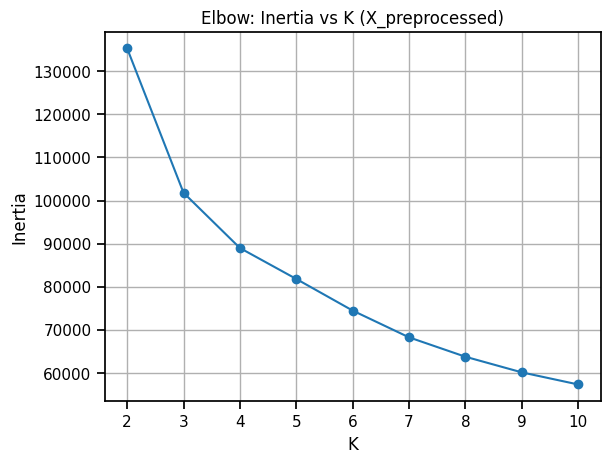

In [76]:
inertias = []
K_range = range(2, 11)

for K in K_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(X_preprocessed)
    inertias.append(km.inertia_)


plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow: Inertia vs K (X_preprocessed)")
plt.grid(True)
plt.show()



,K,inertia,silhouette
0,2,135321.583327,0.403148
1,3,101808.105262,0.293735
2,4,88984.406717,0.287734
3,5,81800.374948,0.252011
4,6,74456.419684,0.227659
5,7,68243.380253,0.214391
6,8,63740.606970,0.217576
7,9,60112.426821,0.206891
8,10,57301.443720,0.209894


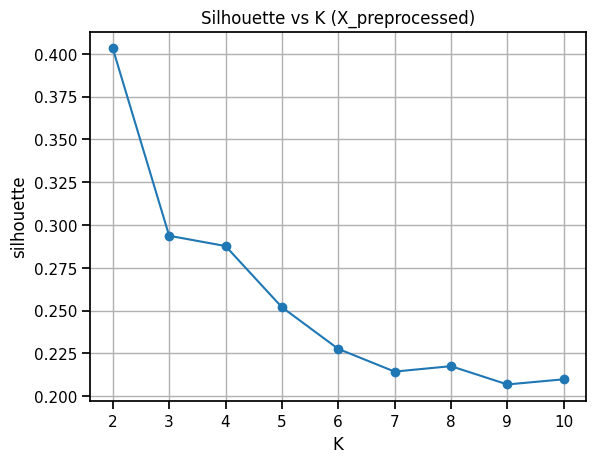

In [77]:
results = []

for K in range(2, 11):
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = km.fit_predict(X_preprocessed)
    sil = silhouette_score(X_preprocessed, labels)
    results.append({ "K": K, "inertia": km.inertia_, "silhouette": sil })

results_df = pd.DataFrame(results)
display(results_df)

plt.figure()
plt.plot(results_df["K"], results_df["silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("silhouette")
plt.title("Silhouette vs K (X_preprocessed)")
plt.grid(True)
plt.show()

In [78]:
K_final = 3
kmeans_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_preprocessed)

print(pd.Series(cluster_labels).value_counts().sort_index())

0     8291
1    10662
2     1687
Name: count, dtype: int64


In [79]:
X_with_clusters = X.copy()
X_with_clusters["cluster"] = cluster_labels

numeric_cols = X_with_clusters.select_dtypes(include=["number"]).columns # enbart numeriska kolumner för profilering.

profile_orig = X_with_clusters[numeric_cols].groupby("cluster").mean()
profile_orig

display(profile_orig.iloc[:, :8])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
cluster,,,,,,,,
0,-121.667340,37.932912,29.631408,2187.914606,435.743605,1109.687010,405.078036,3.745339
1,-118.003978,33.903410,29.767680,2166.589383,454.391675,1268.228756,426.127274,3.912211
2,-119.156117,35.247001,16.634262,7802.000000,1563.475537,3971.292235,1427.758151,4.224095


In [80]:
profile_scaled = X_scaled_df.copy()
profile_scaled["cluster"] = cluster_labels
profile_scaled = profile_scaled.groupby("cluster").mean()
display(profile_scaled.iloc[:, :8])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
cluster,,,,,,,,
0,-1.046995,1.077321,0.078816,-0.205288,-0.241075,-0.278859,-0.247074,-0.065972
1,0.781502,-0.809238,0.089644,-0.215063,-0.197091,-0.138858,-0.192018,0.021866
2,0.206434,-0.180187,-0.953912,2.368136,2.430431,2.248090,2.427854,0.186034


### Tolkning

K‑means med K=3 identifierade tre tydliga grupper av områden:
- Cluster 0: Genomsnittliga områden med medelinkomst och medelstora hushåll.
- Cluster 1: Tätbefolkade områden nära kusten med något högre inkomster.
- Cluster 2: Områden med mycket stora hushåll, många rum och högre medianinkomst – sannolikt mer välbärgade områden.

Silhouette‑värdena är relativt låga (*0.29–0.40*), vilket betyder att klustren överlappar och inte är helt skarpa. Resultaten bör därför tolkas som indikativa mönster, inte som hårda segment.


K‑means visar att det finns viss struktur i datan, med tre breda typer av områden. Detta kan användas som beslutsstöd för segmentering, prioritering eller vidare analys, men klustren är inte helt distinkta och bör kompletteras med annan information.